In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pickle
from monai.data import (
    load_decathlon_datalist,
    list_data_collate
)

In [2]:
import torch

saved_model = torch.load("/home/duong.quang.minh/project/3D-SegClass-Medical/base_ep4k.model", weights_only=False)
saved_model

{'epoch': 4000,
 'state_dict': OrderedDict([('conv_blocks_context.0.0.conv1.weight',
               tensor([[[[[-6.4723e-03,  1.4399e-02, -2.1535e-02],
                          [ 3.8261e-03,  2.4142e-02, -3.6689e-03],
                          [-9.2799e-03,  5.9649e-03, -1.0879e-02]],
               
                         [[ 5.6616e-03,  3.5447e-02, -3.7191e-04],
                          [ 1.8995e-02,  4.0093e-02,  1.7939e-02],
                          [ 5.0008e-03,  7.3787e-03,  9.8435e-04]],
               
                         [[-1.1116e-02,  7.8172e-03, -1.5263e-02],
                          [ 1.9023e-03,  1.2993e-02,  5.0874e-03],
                          [-1.8087e-02,  9.8020e-04, -5.3345e-03]]]],
               
               
               
                       [[[[-8.4413e-02,  5.3741e-02, -1.0522e-01],
                          [ 2.1527e-02,  2.2189e-01,  3.8090e-02],
                          [-6.7915e-02,  2.0316e-02, -1.1823e-01]],
               
         

In [ ]:
import pickle

with open('/home/duong.quang.minh/project/3D-SegClass-Medical/large_ep4k.model.pkl', 'rb') as f:
    data = pickle.load(f)

data

OrderedDict([('init', ('', 0, '', '', False, 0, True, False, True)),
             ('name', 'STUNetTrainer_base'),
             ('plans',
              {'num_stages': 1,
               'num_modalities': 1,
               'modalities': {0: 'nonCT'},
               'normalization_schemes': OrderedDict([(0, 'nonCT')]),
               'num_classes': 104,
               'all_classes': [1,
                2,
                3,
                4,
                5,
                6,
                7,
                8,
                9,
                10,
                11,
                12,
                13,
                14,
                15,
                16,
                17,
                18,
                19,
                20,
                21,
                22,
                23,
                24,
                25,
                26,
                27,
                28,
                29,
                30,
                31,
                32,
  

In [15]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_nib(file_path: str):
    nii_data = nib.load(file_path)

    image_data = nii_data.get_fdata()
    return image_data


In [ ]:
case_id = '00000'
data_path = f'/data/hpc/dqm/data/nnUNet/nnUNet_preprocessed/Dataset137_BraTS2021'

# 2D
preprocessed_npz_path_2d = f'{data_path}/nnUNetPlans_2d/BraTS2021_00000.npz' # data: (4, 146, 171, 136) - 12.243927 - -4.46817 ----- seg: (1, 146, 171, 136) 3 -1
preprocessed_pkl_path_2d = f'{data_path}/nnUNetPlans_2d/BraTS2021_00000.pkl'

# 3D fullres
gt_segmentations_path = f'{data_path}/gt_segmentations/BraTS2021_{case_id}.nii.gz' # (240, 240, 155) - 3.0 - 0.0
preprocessed_seg_path_3d = f'{data_path}/nnUNetPlans_3d_fullres/BraTS2021_{case_id}_seg.npy' # (1, 146, 171, 136) - 3 - -1
preprocessed_image_path_3d = f'{data_path}/nnUNetPlans_3d_fullres/BraTS2021_{case_id}.npy' # (4, 146, 171, 136) - 12.243927 - -4.46817
preprocessed_npz_path_3d = f'{data_path}/nnUNetPlans_3d_fullres/BraTS2021_{case_id}.npz' # data: (4, 146, 171, 136) 12.243927 -4.46817 ----- seg: (1, 146, 171, 136) 3 -1
preprocessed_pkl_path_3d = f'{data_path}/nnUNetPlans_3d_fullres/BraTS2021_{case_id}.pkl'


In [31]:
data = load_npz(preprocessed_npz_path_2d)

In [32]:
data

NpzFile '/data/hpc/dqm/data/nnUNet/nnUNet_preprocessed/Dataset137_BraTS2021/nnUNetPlans_2d/BraTS2021_00000.npz' with keys: data, seg

In [33]:
print(data["data"].shape)
print(data["data"].max())
print(data["data"].min())

print(data["seg"].shape)
print(data["seg"].max())
print(data["seg"].min())

(4, 146, 171, 136)
12.243927
-4.46817
(1, 146, 171, 136)
3
-1


In [ ]:
file_path = '/data/hpc/dqm/unetr_plus_plus/output_synapse/unetr_pp/3d_fullres/Task002_Synapse/unetr_pp_trainer_synapse__unetr_pp_Plansv2.1/fold_0/validation_raw_postprocessed/img0001.nii.gz'
file_path = '/data/hpc/dqm/research-contributions/SwinUNETR/BRATS21/outputs/test1/BraTS2021_00006.nii.gz'

In [2]:

file_path = '/data/hpc/dqm/data/RawData/Training/label/label0007.nii.gz'

nii_data = nib.load(file_path)

# Trích xuất dữ liệu từ file NIfTI
image_data = nii_data.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)

# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data.shape)

print(image_data.max())
print(image_data.min())


# # Hiển thị một lát cắt (slice) của ảnh 3D
# slice_index = 100  # Chọn lát cắt giữa
# plt.imshow(image_data[:, :, slice_index])
# plt.title(f"Slice {slice_index}")
# plt.axis("off")
# plt.show()

Shape of the data: (512, 512, 163)
13.0
0.0


Shape of the data: (240, 240, 155)


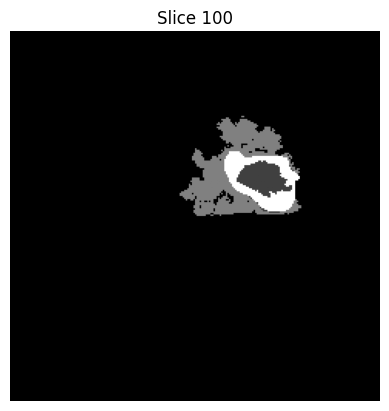

In [2]:
# seg: label
file_path_label = '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01282/BraTS2021_01282_seg.nii.gz'

nii_data_label = nib.load(file_path_label)

# Trích xuất dữ liệu từ file NIfTI
image_data_label = nii_data_label.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data_label.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(image_data_label[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

Shape of the data: (240, 240, 155)


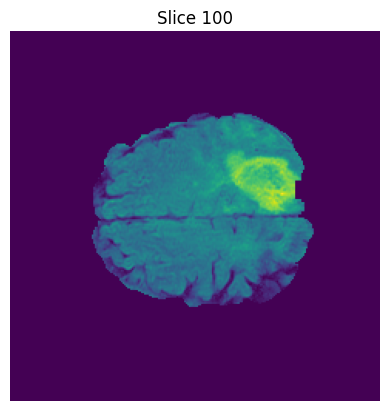

In [12]:
# seg: label
ori_path = '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01282/BraTS2021_01282_flair.nii.gz'

nii_data_ori = nib.load(ori_path)

# Trích xuất dữ liệu từ file NIfTI
nii_data_ori = nii_data_ori.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", nii_data_ori.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(nii_data_ori[:, :, slice_index])
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

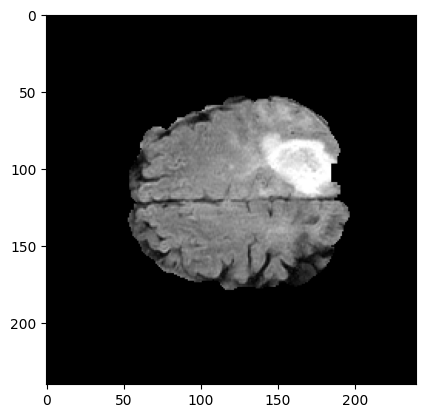

In [15]:
from PIL import Image
plt.imshow(Image.fromarray(nii_data_ori[:, :, slice_index]))

In [6]:
nii_data_ori.max()

400.0

In [7]:
import numpy as np
import cv2

def mask_overlay(image, mask, color_map, alpha=0.5):
    """
    Overlay a mask with multiple colors on top of the grayscale image.
    
    Args:
        image (np.ndarray): Grayscale image (H x W or H x W x 3).
        mask (np.ndarray): Mask with pixel values representing different classes (H x W).
        color_map (dict): Dictionary mapping mask values to RGB colors, e.g., {1: (0, 255, 0), 2: (255, 255, 0)}.
    
    Returns:
        np.ndarray: Image with the mask overlaid.
    """
    # Ensure image is 3-channel (convert grayscale to RGB if needed)
    if image.dtype != np.uint8:  # Đảm bảo ảnh là uint8
        image = (image * 255).astype(np.uint8)
    
    if len(image.shape) == 2:  # Grayscale
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    # Create a copy of the original image
    overlay_image = image.copy()
    
    for mask_value, color in color_map.items():
        # Create a binary mask for the current mask value
        binary_mask = (mask == mask_value).astype(np.uint8)
        
        # Create a color mask for the current mask value
        color_mask = np.dstack([
            binary_mask * color[0],  # Red channel
            binary_mask * color[1],  # Green channel
            binary_mask * color[2],  # Blue channel
        ]).astype(np.uint8)
        
        # Blend the color mask with the original image
        weighted_sum = cv2.addWeighted(color_mask, alpha, overlay_image, 1-alpha, 0.0)
        
        # Apply the mask only on the relevant regions
        overlay_image[binary_mask > 0] = weighted_sum[binary_mask > 0]
    
    return overlay_image


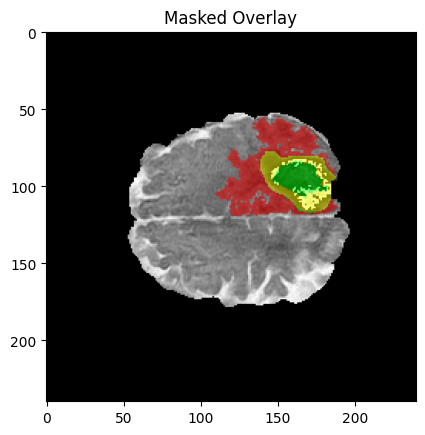

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Ảnh grayscale 2D
grayscale = nii_data_ori[:, :, slice_index]

# Mask 2D có các giá trị 0, 1, 2, 4
mask = image_data_label[:, :, slice_index]

# Bản đồ màu: (1: xanh, 2: đỏ, 3: vàng)
# 0: giữ nguyên ảnh grayscale
color_map = {
    1.0: [0, 255, 0],  # Xanh
    2.0: [255, 0, 0],  # Đỏ
    4.0: [255, 255, 0],  # Vàng
}

# Áp dụng hàm
result_image = mask_overlay(grayscale, mask, color_map)

# Hiển thị kết quả
import matplotlib.pyplot as pl

plt.title("Masked Overlay")
plt.imshow(result_image)  # Chuyển từ BGR sang RGB để hiển thị

plt.show()


In [5]:
image_data.max()

13.0

In [29]:
label = '/data/hpc/dqm/data/DATASET_Synapse/unetr_pp_raw/unetr_pp_cropped_data/Task002_Synapse/gt_segmentations/label0004.nii.gz'

Shape of the data: (512, 512, 147)


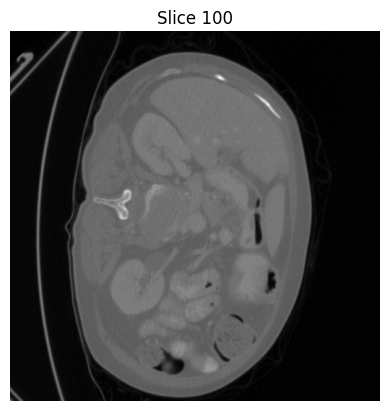

In [30]:

nii_data = nib.load(file_path)

# Trích xuất dữ liệu từ file NIfTI
image_data = nii_data.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)

# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(image_data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [19]:
image_data.max()

2639.0

In [20]:
nii_data

# BTCV


Shape of the data: (512, 512, 94)


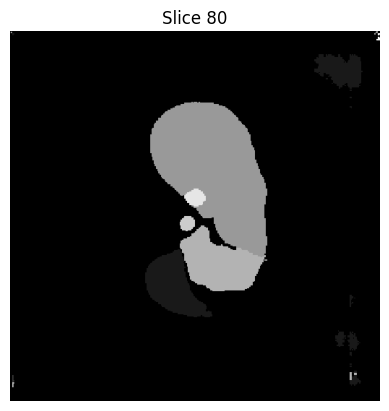

In [4]:

file_path = '/data/hpc/dqm/research-contributions/SwinUNETR/BTCV/outputs/test1/img0035.nii.gz'

nii_data = nib.load(file_path)

# Trích xuất dữ liệu từ file NIfTI
image_data = nii_data.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)

# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 80  # Chọn lát cắt giữa
plt.imshow(image_data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

Shape of the data: (512, 512, 94)


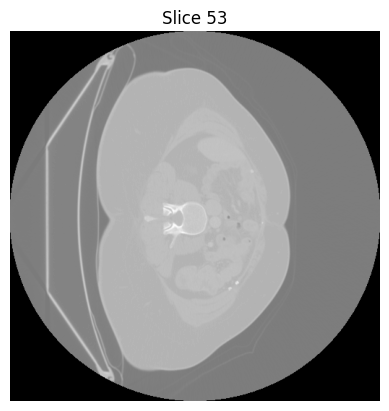

In [14]:
# seg: label
ori_path = '/data/hpc/dqm/research-contributions/UNETR/BTCV/dataset/dataset0/imagesTr/img0035.nii.gz'

nii_data_ori = nib.load(ori_path)

# Trích xuất dữ liệu từ file NIfTI
nii_data_ori = nii_data_ori.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", nii_data_ori.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 53  # Chọn lát cắt giữa
plt.imshow(nii_data_ori[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [9]:
print(image_data[:, :, slice_index].max())
np.any(image_data[:, :, slice_index] == 2.0)


0.0

Shape of the data: (512, 512, 94)


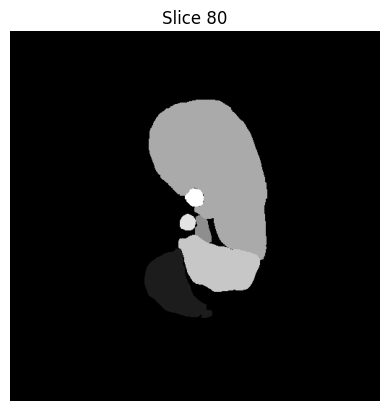

In [11]:
label_tr_path = '/data/hpc/dqm/research-contributions/UNETR/BTCV/dataset/dataset0/labelsTr/label0035.nii.gz'

nii_data_label_tr = nib.load(label_tr_path)

# Trích xuất dữ liệu từ file NIfTI
nii_data_label_tr = nii_data_label_tr.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", nii_data_label_tr.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 80  # Chọn lát cắt giữa
plt.imshow(nii_data_label_tr[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [12]:
print(nii_data_label_tr[:, :, slice_index].max())
np.any(nii_data_label_tr[:, :, slice_index] == 2.0)

9.0


False